## **기본 과제 1 - Tensor의 생성/조작/연산**

### 1) 과제 개요
이번 과제는 PyTorch를 활용한 Tensor의 생성/조작/연산을 중점적으로 진행하게 됩니다. PyTorch에서 Tensor를 다루는 다양한 방법들와 각 방법들의 공통점, 차이점, 유의점에 대해서도 학습할 것입니다.

### 2) 과제 출제 목적 및 배경
PyTorch를 활용해서 AI 모델을 설계 및 제작할 때, Tensor는 필수적으로 다루게 되며 필요에 맞게 Tensor를 올바르게 조작하는 것이 매우 중요합니다.
AI 모델 제작에서 Tensor를 생성하고 Tensor에서 원하는 요소들만 선택하여 가져오거나 Tensor의 모양을 변경하거나 각종 연산들을 수행하는 일은 매우 빈번하게 일어납니다.

이 과제를 통해 Tensor와 혼동되는 개념에 대한 이해를 높이고 이를 실제 AI 개발에 충분히 활용할 수 있기를 바랍니다.

### 3) 과제 수행으로 얻어갈 수 있는 역량
- Tensor 자료형의 종류와 특징을 파악하고 자료형을 알맞게 변환시킬 수 있다.
- 다양한 조건으로 초기화되거나, 초기화되지 않은 Tensor를 생성할 수 있다.
- CUDA 환경을 파악하고 CUDA Tensor의 조작을 이해하여 알맞게 활용할 수 있다.
- Tensor의 모양을 변경하는 방법들을 이해하고 각 방법의 차이점을 파악하여 알맞게 활용할 수 있다.
- 유사도를 구하는 다양한 방법을 이해하여 두 1-D Tensor들의 유사도를 구할 수 있다.
- Tensor를 조작하여 이미지의 데이터 형식을 이해하고 처리할 수 있다.

### 4) 과제 핵심 내용
- Task 1. Tensor의 자료형 조작
- Task 2. Tensor의 생성
- Task 3. CUDA Tensor와 연산
- Task 4. Tensor의 모양 변경
- Task 5. 유사도
- Task 6. Tensor를 활용한 이미지의 이해(응용)
- Task 7. Tensor를 조작하여 이미지 data augmentation 하기(응용)

### 5) Required Package
해당 과제는 Google Colab을 기준으로 제작되었습니다. 실습에서 필요한 패키지 정보는 아래와 같습니다.
```
pytorch >= 2.0.0
requests >= 2.31.0
opencv-python >= 4.8.0
numpy >= 1.25.2
matplotlib >= 3.5.0
```

### 6) Reference
1. https://pytorch.org/docs/stable/tensors.html#data-types
2. https://pytorch.org/docs/stable/generated/torch.transpose.html
3. https://pytorch.org/docs/stable/generated/torch.fliplr.html

### **과제 추가 설명**


여러분이 과제에서 수행해야 할 항목은 총 세 가지이며 모두 **"TODO"** 키워드가 포함되어 있습니다.<br>
**"TODO"** 키워드가 포함된 내용은 **필수로 수행**해야 하는 항목이오니 참고 바랍니다.
1. <font color='green'><b>TODO [ 코드 작성 ]</b></font>
  - `# TODO` 주석을 확인하여 바로 아래 공란에 코드를 작성합니다.
  - `# TODO`가 달려 있지 않은 주석은 comment에 해당합니다.
  - **`변수명: '000'`** 이 표기되어 있으면 새로운 변수명에 대입하라는 뜻이며 변수명이 따로 지정되어 있지 않으면 동일한 변수 이름에 대입하거나 in-place 방식을 활용합니다.
  - 정답은 아래 출력된 내용을 참고하여 확인할 수 있습니다.
2. <font color='blue'><b>TODO [ 퀴즈 ]</b></font>
  - 질문에 대한 답변을 바로 아래 코드 블록에 작성합니다.
3. <font color='orange'><b>TODO [ 탐구 ]</b></font>
  - 참고 자료를 학습하거나 사전에 필요한 내용을 확인 및 수행합니다.

💡 Ctrl+f 로 TODO 를 검색하시면 수행해야 하는 항목을 모두 확인하실 수 있습니다.

<br>

추가로 <font color='red'><b>[ 복습 ] </b></font> 과 <font color='red'><b>[ 유의 ] </b></font> 키워드를 통해 중요하거나 혼동하기 쉬운 개념을 정리해 놓았습니다. 해당 키워드는 수행해야 하는 내용은 아니며 참고용입니다.

<br>

### 필요 라이브러리 import 및 버전 확인

In [1]:
import torch # PyTorch
print("PyTorch version = ", torch.__version__)

import time # python의 시간 관련 내장모듈
import requests # python HTTP 관련 라이브러리

import cv2 # opencv-python 이미지 처리 라이브러리
import numpy as np # 수학 연산 및 행렬 처리를 위한 라이브러리
import matplotlib.pyplot as plt # 시각화 라이브러리

PyTorch version =  2.3.1+cu121


### **Task 1. Tensor의 자료형(Data type) 조작**




> <font color='orange'><b>TODO [ 탐구 ]</b></font>: [텐서의 자료형 문서](https://pytorch.org/docs/stable/tensors.html#data-types)를 읽고 학습합니다.
<br>
<font color='green'><b>TODO [ 코드 작성 ]</b></font>: 텐서의 자료형 확인 및 변환시키기

In [2]:
# TODO 1-1) 10.2의 값을 가지면서 자료형은 64-bit floating point인 1-D Tensor 't'를 정의해 주세요. | 변수명: t
# 단, torch.tensor() 를 이용해 주세요.
# TODO 1-1
t = torch.tensor([10.2], dtype = torch.float64)
print("t: {}".format(t))

# TODO 1-2) t Tensor의 자료형을 출력해 주세요.
# TODO 1-2
print(t.dtype)

if t.dtype == torch.float64:
  print("bytes(t): {} bytes".format(t.untyped_storage().nbytes()))
  print("\n🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("😰 다시 도전해봐요!")

t: tensor([10.2000], dtype=torch.float64)
torch.float64
bytes(t): 8 bytes

🎉🎉🎉 성공!!! 🎉🎉🎉


In [5]:
# TODO 1-3) t Tensor의 자료형을 32-bit integer (signed)로 변환해주세요.
# TODO 1-3
t = t.int()
print("t: ", t)

# TODO 1-4) t Tensor의 자료형을 출력해 주세요.
# TODO 1-4
print(t.dtype)

if t.dtype == torch.int32:
  print("bytes(t): {} bytes".format(t.untyped_storage().nbytes()))
  print("\n🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("😰 다시 도전해봐요!")

t:  tensor([10], dtype=torch.int32)
torch.int32
bytes(t): 4 bytes

🎉🎉🎉 성공!!! 🎉🎉🎉


In [6]:
# TODO 1-5) t Tensor의 자료형을 32-bit floating point로 변환해주세요.
# TODO 1-5
t = t.float()
print("t: ", t)

# TODO 1-6) t Tensor의 자료형을 출력해 주세요.
# TODO 1-6
print(t.dtype)

if t.dtype == torch.float32:
  print("bytes(t): {} bytes".format(t.untyped_storage().nbytes()))
  print("\n🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("😰 다시 도전해봐요!")

t:  tensor([10.])
torch.float32
bytes(t): 4 bytes

🎉🎉🎉 성공!!! 🎉🎉🎉


> <font color='blue'><b>TODO [ 퀴즈 ]</b></font>: 자료형 변환 후 Tensor t의 값이 같은가요?

In [15]:
# TODO 1-7) 위 질문에 대한 답변
print(False)

# ex)
t = torch.tensor([1.5, 2.5, 3.5])
print(t.int())

False
tensor([1, 2, 3], dtype=torch.int32)


> ⚠️ <font color='red'><b>[ 유의 ]</b></font> 자료형 변환 후 Tensor의 값은 달라질 수 있습니다. 자료형 변환 시 의도하지 않게 값이 달라지지 않도록 유의해야 합니다.

### **Task 2. Tensor의 생성**

> <font color='green'><b>TODO [ 코드 작성 ]</b></font>: 다양한 방식으로 텐서를 생성하기

In [22]:
# TODO 2-1) 초기화 되지 않은, [2,4] shape의 tensor를 생성해 주세요. | 변수명 empty_t
# TODO 2-1
empty_t = torch.empty(2, 4)
print('empty_t: {}'.format(empty_t))

# TODO 2-2) empty_t Tensor가 메모리 상에서 유지하는 위치의 고유한 식별자를 확인하여 출력해 주세요.
# TODO 2-2
print(id(empty_t))

# TODO 2-3) empty_t의 요소들에 1로 값을 채워주세요. | 변수명 ones_t
# TODO 2-3
ones_t = torch.fill_(empty_t, 1)
print('ones_t: {}'.format(ones_t))

# TODO 2-4) ones_t Tensor가 메모리 상에서 유지하는 위치의 고유한 식별자를 확인하여 출력해 주세요.
# TODO 2-4
print(id(ones_t))

# TODO 2-5) empty_t 의 요소들에 0으로 값을 채워주세요. 단, in-place 방식을 이용해 주세요. | 변수명 zeros_t
# TODO 2-5
zeros_t = torch.fill_(empty_t, 0)
print('zeros_t: {}'.format(zeros_t))

# TODO 2-6) zeros_t Tensor가 메모리 상에서 유지하는 위치의 고유한 식별자를 확인하여 출력해 주세요.
# TODO 2-6
print(id(zeros_t))

if id(zeros_t) == id(empty_t) and zeros_t.sum() <=1:
  print('\nempty_t: {}'.format(empty_t))
  print('id(empty_t): {}\n'.format(id(empty_t)))
  print("🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("😰 다시 도전해봐요!")

empty_t: tensor([[1.0899e+27, 3.1885e-12, 2.7947e+20, 1.7750e+28],
        [1.8499e+20, 2.9588e+21, 9.1084e-44, 0.0000e+00]])
138457124953424
ones_t: tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.]])
138457124953424
zeros_t: tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.]])
138457124953424

empty_t: tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.]])
id(empty_t): 138457124953424

🎉🎉🎉 성공!!! 🎉🎉🎉


> <font color='blue'><b>TODO [ 퀴즈 ]</b></font>: `zeros_t`의 id 와 `empty_t`의 id 가 같고, 값도 동일한가요? <br>

In [23]:
# TODO 2-7) 위 질문에 대한 답변
print(True)

True


> <font color='blue'><b>TODO [ 퀴즈 ]</b></font>: fill 과 fill_ 는 무엇이 다른가요?

In [27]:
# TODO 2-8) 위 질문에 대한 답변
print("fill 메모리 주소를 변경하여 데이터를 수정하는 과정(new), \nfill_은 메모리 주소를 변경하지 않고 다른 데이터로 수정하는 과정(in-place)")

fill 메모리 주소를 변경하여 데이터를 수정하는 과정(new), 
fill_은 메모리 주소를 변경하지 않고 다른 데이터로 수정하는 과정(in-place)


In [2]:
import torch

In [12]:
# TODO 2-9) 크기가 30인 표준정규분포 난수 Tensor를 생성해 주세요. | 변수명 rand_t
# TODO 2-9
rand_t = torch.rand(30)

# TODO 2-10) rand_t의 shape 을 출력해 주세요.
# TODO 2-10
print(rand_t.shape) # torch.Size([30])

# TODO 2-11) rand_t가 0차원은 1, 1차원은 3을 가지도록 shape을 변경해 주세요. | 변수명 v_t
# 단, torch.Tensor.view를 활용해 주세요.
# TODO 2-11
v_t = rand_t.view(1, 3, -1)

print("v_t.shape: {}".format(v_t.shape))

# TODO 2-12) v_t 와 shape이 같으면서 1으로 채워진 Tensor를 생성해 주세요. | 변수명 ones_t
# TODO 2-12
ones_t = torch.ones_like(v_t)

if ones_t.shape[-1] == 10:
  print("ones_t.shape: {}".format(ones_t.shape))
  print("ones_t: {}".format(ones_t))
  print("\n🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("\n😰 다시 도전해봐요!")

torch.Size([30])
v_t.shape: torch.Size([1, 3, 10])
ones_t.shape: torch.Size([1, 3, 10])
ones_t: tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]])

🎉🎉🎉 성공!!! 🎉🎉🎉


### **Task 3. CUDA Tensor와 연산**

> <font color='orange'><b>TODO [ 탐구 ]</b></font>: Colab에서 GPU를 사용할 수 있는 방법을 탐구합니다.
- 런타임 ➡️ 런타임 유형 변경 ➡️ ***T4 GPU*** 선택 ➡️ 저장

> <font color='green'><b>TODO [ 코드 작성 ]</b></font>: CUDA 환경 확인 후 CUDA Tensor 생성, 조작하기

In [7]:
# TODO 3-1) CUDA를 사용할 수 있는 환경인지 확인하여 출력해 주세요.
# TODO 3-1
print(torch.cuda.is_available())

# TODO 3-2) 사용 가능한 GPU 개수를 확인하여 출력해 주세요.
# TODO 3-2
print(torch.cuda.device_count())

# TODO 3-3) CUDA device의 이름을 확인하여 출력해 주세요.
# TODO 3-3
print(torch.cuda.get_device_name(device = 0))

# TODO 3-4) CUDA가 사용 가능하면 'cuda'를, 그렇지 않으면 'cpu'를 device라는 변수명에 대입해 주세요. | 변수명: device
# TODO 3-4
device = 'cuda' if torch.cuda.is_available() else 'cpu'

if device == 'cuda':
  print("\n🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("\n😰 다시 도전해봐요!")

True
1
Tesla T4

🎉🎉🎉 성공!!! 🎉🎉🎉


In [22]:
# TODO 3-5) 0에서 1000까지 0.001 간격으로 1-D Tensor를 생성해 주세요. | 변수명: tensor_1
# TODO 3-5
tensor_1 = torch.arange(0, 1000, 0.001)

# TODO 3-6) 0에서 10000까지 0.01 간격으로 1-D Tensor를 생성해 주세요. | 변수명: tensor_2
# TODO 3-6
tensor_2 = torch.arange(0, 10000, 0.01)

if tensor_1.shape[0] == 1000000 and tensor_2.shape[0] == 1000000:
  print("🎉🎉🎉 성공!!! 🎉🎉🎉")
  print("\ntensor_1(device): {}, tensor_2(device): {}".format(tensor_1.device, tensor_2.device))
else:
  print("😰 다시 도전해봐요!")

🎉🎉🎉 성공!!! 🎉🎉🎉

tensor_1(device): cpu, tensor_2(device): cpu


> <font color='blue'><b>TODO [ 퀴즈 ]</b></font>: 현재 tensor_1 과 tensor_2 는 어느 디바이스에 할당되어 있나요?

In [28]:
# TODO 3-7) 위 질문에 대한 답변
print("tensor_1(device): cpu, tensor_2(device): cpu")

tensor_1(device): cpu, tensor_2(device): cpu


In [25]:
import time

def tensor_operations(t1, t2, prt=True):
  ot1 = t1.clone()
  ot2 = t2.clone()
  start_time = time.time()

  # TODO 3-8) in-place 방식을 활용하여 t1에 t2를 더해주세요.
  # TODO 3-8
  t1.add_(t2)

  # TODO 3-9) t1에서 t2를 뺀 후 t3에 대입해 주세요. | 변수명: t3
  # TODO 3-9
  t3 = torch.sub(t1, t2)

  # TODO 3-10) in-place 방식을 활용하여 t3에 1.2를 곱해 주세요.
  # TODO 3-10
  t3.mul_(1.2)

  # TODO 3-11) t3에서 2를 나눈 후 t4에 대입해 주세요. | 변수명: t4
  # TODO 3-11
  t4 = torch.div(t3, 2)

  # TODO 3-12) in-place 방식을 활용하여 t4를 2 제곱해 주세요.
  # TODO 3-12
  t4.pow_(2)

  end_time = time.time()
  if prt:
    print("Elapsed time: {:.5f}ms".format((end_time-start_time)*1000))

    if t4.max() - ((1.2*ot1/2)**2).max() <= t4.max() / 10:
        print("\n🎉🎉🎉 성공!!! 🎉🎉🎉")
    else:
        print("\n🙅 다시 도전해봐요!")

In [26]:
# %%time
tensor_operations(tensor_1, tensor_2, False)

# 위에서 정의한 함수 tensor_operations에 tensor_1과 tensor_2를 인자로 넣어 실행
tensor_operations(tensor_1, tensor_2)

Elapsed time: 6.69980ms

🎉🎉🎉 성공!!! 🎉🎉🎉


In [27]:
# TODO 3-13) 기존에 정의했던 'device' 변수를 활용해 tensor_1를 CUDA Tensor로 변환시켜 주세요 | 변수명: tensor_c1
# TODO 3-13
tensor_c1 = tensor_1.to('cuda')

# TODO 3-14) .cuda()를 활용해 tensor_2를 CUDA Tensor로 변환시켜 주세요. | 변수명: tensor_c2
# TODO 3-14
tensor_c2 = tensor_2.cuda()

if tensor_c1.device == 'cpu' or tensor_c2.device == 'cpu':
  print("😰 다시 도전해봐요!")
else:
  print("tensor_c1(device): {}, tensor_c2(device): {}".format(tensor_c1.device, tensor_c2.device))
  print("\n🎉🎉🎉 성공!!! 🎉🎉🎉")

tensor_c1(device): cuda:0, tensor_c2(device): cuda:0

🎉🎉🎉 성공!!! 🎉🎉🎉


> <font color='blue'><b>TODO [ 퀴즈 ]</b></font>: 현재 `tensor_c1`과 `tensor_c2`는 어느 디바이스에 할당되어 있나요?

In [29]:
# TODO 3-15) 위 질문에 대한 답변
print("tensor_c1(device): cuda:0, tensor_c2(device): cuda:0")

tensor_c1(device): cuda:0, tensor_c2(device): cuda:0


In [30]:
# %%time
tensor_operations(tensor_c1, tensor_c2, False)

# 위에서 정의한 함수 tensor_operations에 tensor_c1 과 tensor_c2 를 인자로 넣어 실행
tensor_operations(tensor_c1, tensor_c2)

Elapsed time: 0.12803ms

🎉🎉🎉 성공!!! 🎉🎉🎉


> <font color='blue'><b>TODO [ 퀴즈 ]</b></font>: CUDA Tensor의 연산과 CPU Tensor의 연산 중 어느 것이 더 빨랐나요?

In [31]:
# TODO 3-16) 위 질문에 대한 답변
print("CUDA Tensor")

CUDA Tensor


> 💡 <font color='red'><b> [ 복습 ]</b></font> GPU는 수 천 개의 작은 코어를 가지고 있어 병렬 데이터 처리에 매우 효율적입니다. 즉, 대량의 연산을 동시에 수행하는 데 용이합니다. GPU의 병렬 처리 능력은 Tensor의 연산 속도를 향상시켜 AI 모델의 훈련과 추론 속도를 크게 향상시킬 수 있습니다.

### **Task 4. Tensor의 모양 변경**

> <font color='green'><b>TODO [ 코드 작성 ]</b></font>: Tensor의 모양 변경하기

In [43]:
# TODO 4-1) 0부터 10까지 1씩 증가하는 1-D Tensor를 생성해 주세요. | 변수명: t
# TODO 4-1
t = torch.arange(0, 10, 1)
print("t.shape: {}".format(t.shape))

# TODO 4-2) t Tensor의 shape을 [2, 5]로 변경해 주세요. 단, reshape을 사용해 주세요. | 변수명: reshaped_t
# TODO 4-2
reshaped_t = t.reshape(2, 5)

# TODO 4-3) reshaped_t Tensor의 shape을 확인하여 출력해 주세요.
# TODO 4-3
print(reshaped_t.shape)

# TODO 4-4) t Tensor의 shape 을 [2, 5]로 변경해 주세요. 단, view를 사용해 주세요. | 변수명: v_t
# TODO 4-4
v_t = t.view([2, 5])

# TODO 4-5) v_t Tensor의 shape을 확인하여 출력해 주세요.
# TODO 4-5
print(v_t.shape)

if reshaped_t.shape[-1] == 5 and v_t.shape[-1] == 5:
  print("\n🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("\n😰 다시 도전해봐요!")

t.shape: torch.Size([10])
torch.Size([2, 5])
torch.Size([2, 5])

🎉🎉🎉 성공!!! 🎉🎉🎉


In [50]:
# TODO 4-6) v_t Tensor의 contiguous 속성을 확인하여 출력해 주세요.
# TODO 4-6
print(v_t.is_contiguous())

# TODO 4-7) v_t Tensor에서 0차원은 전부, 1차원은 0번째 요소부터 3번째요소까지(포함) 선택하여 가져와 주세요. | 변수명: sliced_t
# TODO 4-7
sliced_t = v_t[:, 0:4]
print(sliced_t)

# TODO 4-8) sliced_t Tensor의 contiguous 속성을 확인하여 출력해 주세요.
# TODO 4-8
print(sliced_t.is_contiguous())

if sliced_t.shape[-1] == 4 and sliced_t.is_contiguous() == False:
  print("\n🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("😰 다시 도전해봐요!")

True
tensor([[0, 1, 2, 3],
        [5, 6, 7, 8]])
False

🎉🎉🎉 성공!!! 🎉🎉🎉


> <font color='blue'><b>TODO [ 퀴즈 ]</b></font>: `sliced_t` Tensor는 view를 사용할 수 있을까요?

In [55]:
# TODO 4-9) 위 질문에 대한 답변
print(False)

False


In [56]:
test_t = sliced_t.view([-1])

RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.

> <font color='blue'><b>TODO [ 퀴즈 ]</b></font>: `sliced_t` Tensor는 view를 사용해 모양을 바꾸려고 할 때 왜 RuntimeError가 발생할까요?

In [57]:
# TODO 4-10) 위 질문에 대한 답변
print("view는 메모리가 비연속적일 때 사용이 불가능합니다.")

view는 메모리가 비연속적일 때 사용이 불가능합니다.


> ⚠️ <font color='red'><b> [ 유의 ]</b></font> view() 메서드는 Tensor의 메모리가 연속적으로 할당된 경우에 다시 말해, is_contiguous 속성이 True인 경우에만 사용이 가능합니다.

In [60]:
# TODO 4-11) reshape을 활용하여 sliced_t를 평탄화 해주세요. | 변수명 r_t
# TODO 4-11
r_t = sliced_t.reshape(-1)
print("r_t.shape: {}".format(r_t.shape))
print("r_t: ", r_t)

# TODO 4-12) reshape을 쓰지 않고 sliced_t를 평탄화 해주세요. | 변수명 f_t
# TODO 4-12
f_t = sliced_t.flatten()
print("f_t.shape: {}".format(f_t.shape))
print("f_t: ", f_t)

if len(r_t.shape) == 1 and len(f_t.shape) == 1:
  print("\n🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("😰 다시 도전해봐요!")

r_t.shape: torch.Size([8])
r_t:  tensor([0, 1, 2, 3, 5, 6, 7, 8])
f_t.shape: torch.Size([8])
f_t:  tensor([0, 1, 2, 3, 5, 6, 7, 8])

🎉🎉🎉 성공!!! 🎉🎉🎉


In [68]:
# TODO 4-13) 0번째 차원은 1, 1번째 차원은 2, 2번째 차원은 2, 3번째 차원은 1, 4번째 차원은 나머지를 가지도록 sliced_t의 shape을 변경해 주세요.
# 단, torch.reshape을 활용해 주세요. | 변수명: reshaped_t
# TODO 4-13
reshaped_t = torch.reshape(sliced_t, (1, 2, 2, 1, 2))
print("reshaped_t.shape: {}\n".format(reshaped_t.shape))

# TODO 4-14) reshaped_t Tensor의 2번째 차원부터 마지막 차원까지 평탄화를 수행해 주세요. | 변수명: flatten_t
# TODO 4-14
flatten_t = torch.flatten(reshaped_t, start_dim=2)
print("flatten_t.shape: {}".format(flatten_t.shape))
print("flatten_t : {}".format(flatten_t))

if flatten_t.shape[0] == 1 and flatten_t.shape[-1] == 4:
  print("\n🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("😰 다시 도전해봐요!")

reshaped_t.shape: torch.Size([1, 2, 2, 1, 2])

flatten_t.shape: torch.Size([1, 2, 4])
flatten_t : tensor([[[0, 1, 2, 3],
         [5, 6, 7, 8]]])

🎉🎉🎉 성공!!! 🎉🎉🎉


In [96]:
# TODO 4-15) 0부터 12까지 1씩 증가하는 1-D Tensor를 생성해 주세요. | 변수명: t
# TODO 4-15
t = torch.arange(0, 12, 1)
print("t: {}".format(t))

# TODO 4-16) t Tensor의 shape을 [2, 2, 3]으로 변경해 주세요.
# 단 .reshape 메서드를 활용해 주세요.
# TODO 4-16
t = t.reshape(2, 2, 3)
print("t: {}\n".format(t))

# TODO 4-17) t Tensor의 2번째 차원과 1번째 차원을 바꾸어 주세요. | 변수명: transposed_t
# TODO 4-17
transposed_t = t.transpose(1, 2)
print("transposed_t: \n{}".format(transposed_t))
print("transposed_t.shape: {}\n".format(transposed_t.shape))

# TODO 4-18) 차원의 축을 변경하지 않고 t Tensor의 shape 을 [2, 3, 나머지]로 변경해 주세요. | 변수명: reshaped_t
# TODO 4-18
reshaped_t = t.reshape(2, 3, -1)
print("reshaped_t: \n{}".format(reshaped_t))
print("reshaped_t.shape: {}\n".format(reshaped_t.shape))

if transposed_t.shape == reshaped_t.shape and transposed_t[0, 0, 1] != reshaped_t[0, 0, 1]:
  print("🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("😰 다시 도전해봐요!")

t: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
t: tensor([[[ 0,  1,  2],
         [ 3,  4,  5]],

        [[ 6,  7,  8],
         [ 9, 10, 11]]])

transposed_t: 
tensor([[[ 0,  3],
         [ 1,  4],
         [ 2,  5]],

        [[ 6,  9],
         [ 7, 10],
         [ 8, 11]]])
transposed_t.shape: torch.Size([2, 3, 2])

reshaped_t: 
tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]]])
reshaped_t.shape: torch.Size([2, 3, 2])

🎉🎉🎉 성공!!! 🎉🎉🎉


> <font color='blue'><b>TODO [ 퀴즈 ]</b></font>: t에 reshape을 적용한 `reshaped_t` 와 transpose를 적용한 `transposed_t` 의 결과는 같나요? 모양은 같은가요?

In [74]:
# TODO 4-19) 위 질문에 대한 답변
print(False)

False


> <font color='orange'><b>TODO [ 탐구 ]</b></font>: [transpose의 PyTorch document](https://pytorch.org/docs/stable/generated/torch.transpose.html)를 읽고 reshape과 다른 점을 탐구합니다.

> 💡 <font color='red'><b> [ 복습 ]</b></font> transpose는 reshape과 달리 Tensor의 특정한 두 차원의 **축을 서로 바꾸는** 메서드입니다.

In [97]:
# TODO 4-20) t Tensor에서 0차원으로 dim이 1인 특정 차원을 확장해 주세요.
# TODO 4-20
t = torch.unsqueeze(t, dim=0)
print("t.shape: {}".format(t.shape))

# TODO 4-21) t Tensor에서 2차원으로 dim이 1인 특정 차원을 확장해 주세요.
# TODO 4-21
t = torch.unsqueeze(t, dim=2)
print("t.shape: {}".format(t.shape))

# TODO 4-22) t Tensor에서 마지막 차원으로 dim이 1인 특정 차원을 확장해 주세요.
# TODO 4-22
t = torch.unsqueeze(t, dim=-1)
print("t.shape: {}".format(t.shape))

if len(t.shape) == 6:
  print("\n🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("\n😰 다시 도전해봐요!")

t.shape: torch.Size([1, 2, 2, 3])
t.shape: torch.Size([1, 2, 1, 2, 3])
t.shape: torch.Size([1, 2, 1, 2, 3, 1])

🎉🎉🎉 성공!!! 🎉🎉🎉


In [98]:
print("t.shape: {}".format(t.shape))
s_t = torch.squeeze(t, dim=1)
print("s_t.shape: {}".format(s_t.shape))

# TODO 4-23) s_t Tensor에서 0번째 차원에 dim이 1인 특정 차원을 축소해 주세요.
# TODO 4-23
s_t = torch.squeeze(t, dim=0)
print("s_t.shape: {}".format(s_t.shape))

if len(s_t.shape) == 5:
  print("\n🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("\n😰 다시 도전해봐요!")

t.shape: torch.Size([1, 2, 1, 2, 3, 1])
s_t.shape: torch.Size([1, 2, 1, 2, 3, 1])
s_t.shape: torch.Size([2, 1, 2, 3, 1])

🎉🎉🎉 성공!!! 🎉🎉🎉


> <font color='blue'><b>TODO [ 퀴즈 ]</b></font>: 왜 `torch.squeeze(t, dim=1)`에서는 아무 변화가 없고 `torch.squeeze(t, dim=0)`에서는 차원 축소가 일어났을까요?

In [100]:
# TODO 4-24) 위 질문에 대한 답변
print("차원의 크기가 1인 경우에만 차원을 축소하기 때문에 이 함수는 dim 파라미터를 통해 특정 차원만을 대상으로 축소할 수 있으며, 만약 그 차원의 크기가 1이 아닐 경우에는 아무 변화도 일어나지 않습니다.")

차원의 크기가 1인 경우에만 차원을 축소하기 때문에 이 함수는 dim 파라미터를 통해 특정 차원만을 대상으로 축소할 수 있으며, 만약 그 차원의 크기가 1이 아닐 경우에는 아무 변화도 일어나지 않습니다.


In [101]:
# TODO 4-25) s_t Tensor에서 dim이 1인 모든 차원을 축소해 주세요.
# TODO 4-25
s_t = torch.squeeze(s_t)
print("s_t.shape: {}".format(s_t.shape))

if len(s_t.shape) == 3:
  print("\n🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("\n😰 다시 도전해봐요!")

s_t.shape: torch.Size([2, 2, 3])

🎉🎉🎉 성공!!! 🎉🎉🎉


### **Task 5. 유사도**

> <font color='green'><b>TODO [ 코드 작성 ]</b></font>: Tensor vector operations를 활용해 맨해튼/유클리드/코사인 유사도를 구하기

In [1]:
import torch

In [11]:
# 맨해튼 유사도를 구하는 함수를 정의
def get_manhattan_similarity(t1, t2):
  # TODO 5-1) t1, t2 Tensor의 맨해튼 거리를 구하는 코드를 작성해 주세요. | 변수명: manhattan_distance
  # TODO 5-1
  manhattan_distance =  torch.norm(t1 - t2, p = 1)
  # TODO 5-2) 맨해튼 거리를 이용하여 맨해튼 유사도를 구하는 코드를 작성해 주세요. | 변수명: manhattan_similarity
  # TODO 5-2
  manhattan_similarity = 1/(1+manhattan_distance)
  print("manhattan_similarity: {}".format(manhattan_similarity))

  # TODO 5-3) 맨해튼 유사도를 반환해 주세요.
  return manhattan_similarity # TODO 5-3

In [12]:
# 유클리드 유사도를 구하는 함수를 정의
def get_euclidean_similarity(t1, t2):
  # TODO 5-4) t1, t2 Tensor의 유클리드 거리를 구하는 코드를 작성해 주세요. | 변수명: euclidean_distance
  # TODO 5-4
  euclidean_distance = torch.norm(t1-t2, 2)
  # TODO 5-5) 유클리드 거리를 이용하여 유클리드 유사도를 구하는 코드를 작성해 주세요. | 변수명: euclidean_similarity
  # TODO 5-5
  euclidean_similarity = 1 / (1 + euclidean_distance)
  print("euclidean_similarity: {}".format(euclidean_similarity))

  # TODO 5-6) 유클리드 유사도를 반환해 주세요.
  return euclidean_similarity # TODO 5-6

In [16]:
# 코사인 유사도를 구하는 함수를 정의
def get_cosine_similarity(t1, t2):
  # TODO 5-7) t1, t2 Tensor의 내적을 이용하여 코사인 유사도를 구하는 코드를 작성해 주세요. | 변수명: cosine_similarity
  # TODO 5-7
  cosine_similarity = torch.dot(t1, t2) / (torch.norm(t1, p = 2) * (torch.norm(t2, p = 2)))
  print("cosine_similarity: {}".format(cosine_similarity))

  # TODO 5-8) 코사인 유사도를 반환해 주세요.
  return cosine_similarity # TODO 5-8

In [17]:
t1 = torch.tensor([1., 2., 0., 3., 5.])
t2 = torch.tensor([2., 1., 1., 1., 0.])

# TODO 5-9) 위에서 정의한 맨해튼 유사도를 구하는 함수로 t1, t2 두 Tensor의 맨해튼 유사도를 구해 주세요. | 변수명: manhattan_s
# TODO 5-9
manhattan_s = get_manhattan_similarity(t1, t2)

# TODO 5-10) 위에서 정의한 유클리드 유사도를 구하는 함수로 t1, t2 두 Tensor의 유클리드 유사도를 구해 주세요. | 변수명: euclidean_s
# TODO 5-10
euclidean_s = get_euclidean_similarity(t1, t2)

# TODO 5-11) 위에서 정의한 코사인 유사도를 구하는 함수를 사용하여 t1, t2 두 Tensor의 코사인 유사도를 구해 주세요. | 변수명 cosine_s
# TODO 5-11
cosine_s = get_cosine_similarity(t1, t2)

if manhattan_s <= 0.1 and euclidean_s <= 0.2 and cosine_s <= 0.5:
  print("\n🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("\n😰 다시 도전해봐요!")

manhattan_similarity: 0.09090909361839294
euclidean_similarity: 0.1502211093902588
cosine_similarity: 0.4236592948436737

🎉🎉🎉 성공!!! 🎉🎉🎉


### **Task 6. Tensor를 활용한 이미지의 이해(응용)**

> <font color='green'><b>TODO [ 코드 작성 ]</b></font>: Tensor를 조작하여 이미지 처리하기 (채널 분리하기)

In [30]:
import numpy as np
import requests
import cv2
import matplotlib.pyplot as plt

In [31]:
url = 'https://github.com/AI-rndt/BoostCamp_PyTorch/blob/main/images/rgb_image.jpg?raw=true'
image = bytearray(requests.get(url).content) # url로부터 content 가져오기
image = np.asarray(image, dtype=np.uint8) # numpy array로 변환하기
image = cv2.imdecode(image, cv2.IMREAD_COLOR) # opencv를 활용하여 image data decode하기
print(image.shape)

(1024, 1280, 3)


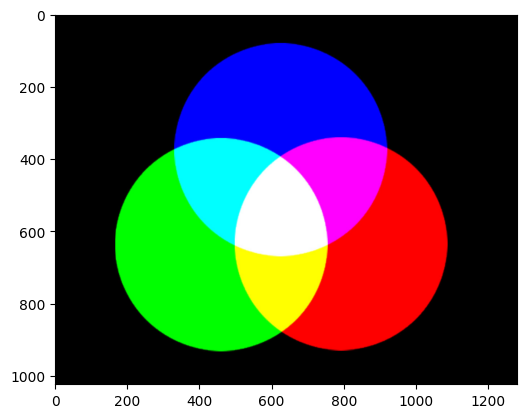

In [32]:
plt.imshow(image)

> 💡 <font color='red'><b> [ 복습 ]</b></font>: 컬러 이미지는 red, green, blue 세 개의 채널로 이루어져 있습니다. 세 개의 채널이 조합되어 하나의 컬러 이미지를 출력하게 됩니다. 반면, 흑백 이미지는 하나의 채널만을 가집니다.

In [52]:
# TODO 6-1) numpy array인 image로 부터 Tensor를 생성해 주세요. | 변수명: img_t
# TODO 6-1
img_t = torch.tensor(image)
print(img_t.shape)
# TODO 6-2) img_t의 data type을 출력해 주세요.
# TODO 6-2
print(img_t.dtype)

if type(img_t) == torch.Tensor:
  print("\n🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("\n🙅 다시 도전해봐요!")

torch.Size([1024, 1280, 3])
torch.uint8

🎉🎉🎉 성공!!! 🎉🎉🎉


> 💡 <font color='red'><b> [ 복습 ]</b></font>: 일반적으로 이미지는 픽셀들로 이루어져 있어 픽셀들의 집합, 배열이라고 볼 수 있습니다. 이미지 크기만큼 (height * width) 픽셀이 존재하며 하나의 픽셀은 r, g, b 세 개(채널)의 값을 가집니다.

> 💡 <font color='orange'><b> [ 탐구 ]</b></font>: 주요 픽셀들의 위치와 픽셀의 r, g, b 값을 직접 확인해볼까요?

In [46]:
# TODO 6-3) img_t Tensor에서 0차원은 800번째이면서 1차원은 800번째인 요소들을 slicing하여 pixel에 대입해 주세요. | 변수명: pixel
# 위 그림을 참고하였을 때 행의 위치는 800, 열의 위치는 800인 픽셀의 값
# TODO 6-3
pixel = img_t[800, 800]

if pixel[0] >= 200:
  print("pixel position - (800, 800): {}\n".format(pixel))
  print("🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("🙅 다시 도전해봐요!")

pixel position - (800, 800): tensor([254,   0,   0], dtype=torch.uint8)

🎉🎉🎉 성공!!! 🎉🎉🎉


> 💡 <font color='red'><b> [ 복습 ]</b></font>: torch.uint8은 0~255 사이의 값을 가집니다.

In [43]:
# TODO 6-4) img_t Tensor에서 0차원은 800번째이면서 1차원은 400번째인 요소들을 slicing하여 출력해 주세요. | 변수명: pixel
# 위 그림을 참고하였을 때 행의 위치는 800, 열의 위치는 400인 픽셀의 값
# TODO 6-4
pixel = img_t[800, 400]

if pixel[1] >= 200:
  print("pixel position - (800, 400): {}\n".format(pixel))
  print("🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("🙅 다시 도전해봐요!")

pixel position - (800, 400): tensor([  0., 255.,   0.])

🎉🎉🎉 성공!!! 🎉🎉🎉


In [44]:
# TODO 6-5) img_t Tensor에서 0차원은 200번째이면서 1차원은 600번째인 요소들을 slicing하여 출력해 주세요. | 변수명: pixel
# 위 그림을 참고하였을 때 행의 위치는 200, 열의 위치는 600인 픽셀의 값
# TODO 6-5
pixel = img_t[200, 600]

if pixel[2] >= 200:
  print("pixel position - (200, 600): {}\n".format(pixel))
  print("🎉🎉🎉 성공!!! 🎉🎉🎉")
else:
  print("🙅 다시 도전해봐요!")

pixel position - (200, 600): tensor([  0.,   0., 254.])

🎉🎉🎉 성공!!! 🎉🎉🎉


> <font color='blue'><b>TODO [ 퀴즈 ]</b></font>: 6-3, 6-4, 6-5 코드의 출력 결과와 위 이미지 상의 픽셀 위치를 종합적으로 고려했을 때 `img_t` Tensor의 마지막 차원에서 red, green, blue 채널은 각각 몇 번째 채널에 해당될까요?

In [47]:
# TODO 6-6) 위 질문에 대한 답변
print({"red": 0, "green": 1, "blue": 2})

{'red': 0, 'green': 1, 'blue': 2}


In [68]:
def show_red_channel(img_tensor):
  # TODO 6-7) img_t에서 red 채널만 선택해 red_only에 대입해 주세요. | 변수명: red_only
  # TODO 6-7
  red_only = img_tensor[:, :, 0]

  # TODO 6-8) red_only의 마지막 차원을 확장하여 dim이 1이 되도록 만들어 주세요.
  # 단, unsqueeze를 활용해 주세요.
  # TODO 6-8
  red_only = red_only.unsqueeze(-1)

  # TODO 6-9) red_only와 모양이 같으면서 0으로 채워진 Tensor를 만들어 주세요. | 변수명: zero_t
  # TODO 6-9
  zero_t = torch.zeros_like(red_only)

  # TODO 6-10) zero_t를 dim=0/dim=1축으로는 1번, dim=2축으로만 2번 *반복하여 Tensor의 크기를 확장해 주세요. | 변수명: zeros_t
  # TODO 6-10
  zeros_t = zero_t.repeat(1, 1, 2)

  # TODO 6-11) red_only와 zeros_t를 마지막 차원을 기준으로 연결해 주세요. | 변수명: red_img_t
  # TODO 6-11
  red_img_t = torch.cat((red_only, zeros_t), dim=-1)

  # TODO 6-12) red_img_t Tensor를 numpy array로 변환해 주세요. | 변수명: red_img
  # TODO 6-12
  red_img = red_img_t.numpy()

  if red_img.shape == image.shape and red_img[:, :, 1:].sum() <= 1:
    print("🎉🎉🎉 성공!!! 🎉🎉🎉")
  else:
    print("🙅 다시 도전해봐요!")
    return None

  plt.imshow(red_img)
  return red_only

🎉🎉🎉 성공!!! 🎉🎉🎉


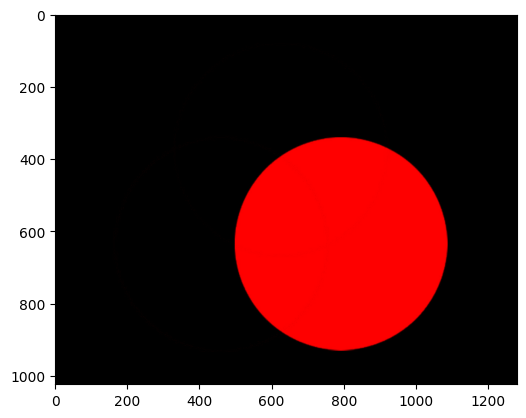

In [69]:
red_t = show_red_channel(img_t)

In [75]:
def show_blue_channel(img_tensor):
  # TODO 6-13) img_t에서 blue 채널만 선택해 blue_only에 대입해 주세요. | 변수명: blue_only
  # TODO 6-13
  blue_only = img_tensor[:, :, 2]

  # TODO 6-14) blue_only의 마지막 차원을 확장하여 dim이 1이 되도록 만들어 주세요.
  # 단, unsqueeze를 활용해 주세요.
  # TODO 6-14
  blue_only = blue_only.unsqueeze(-1)

  # TODO 6-15) blue_only와 모양이 같으면서 0으로 채워진 Tensor를 만들어 주세요. | 변수명: zero_t
  # TODO 6-15
  zero_t = torch.zeros_like(blue_only)

  # TODO 6-16) zero_t를 dim=0/dim=1축으로는 1번, dim=2축으로만 2번 *반복하여 Tensor의 크기를 확장해 주세요. | 변수명: zeros_t
  # TODO 6-16
  zeros_t = zero_t.repeat(1, 1, 2)

  # TODO 6-17) zeros_t와 blue_only를 마지막 차원을 기준으로 연결해 주세요. | 변수명: blue_img_t
  # 단, 순서에 유의해 주세요. blue channel이 마지막 채널에 배치되도록 연결해 주세요.
  # TODO 6-17
  blue_img_t = torch.cat([zeros_t, blue_only], dim = -1)

  # TODO 6-18) blue_img_t Tensor를 numpy array로 변환해 주세요. | 변수명: blue_img
  # TODO 6-18
  blue_img = blue_img_t.numpy()

  if blue_img.shape == image.shape and blue_img[:, :, :2].sum() <= 1:
    print("🎉🎉🎉 성공!!! 🎉🎉🎉")
  else:
    print("🙅 다시 도전해봐요!")
    return None

  plt.imshow(blue_img)
  return blue_only

🎉🎉🎉 성공!!! 🎉🎉🎉


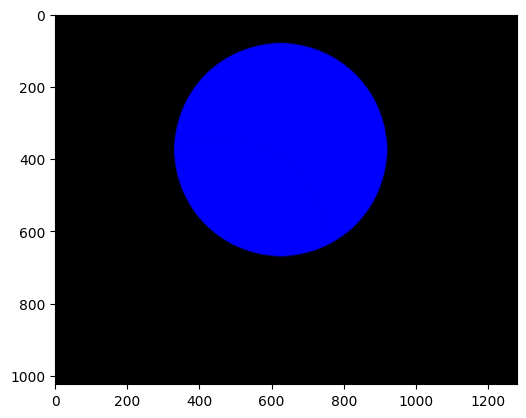

In [76]:
blue_t = show_blue_channel(img_t)

In [78]:
def show_green_channel(img_tensor):
  # TODO 6-19) img_t에서 green 채널만 선택해 green_only에 대입해 주세요. | 변수명: green_only
  # TODO 6-19
  green_only = img_tensor[:, :, 1]

  # TODO 6-20) green_only와 모양이 같으면서 0으로 채워진 Tensor를 만들어 주세요. | 변수명: zero_t
  # TODO 6-20
  zero_t = torch.zeros_like(green_only)

  # TODO 6-21) 마지막 차원을 기준으로 zero_t에 green_t를 쌓고 다시 zero_t를 쌓아 주세요. | 변수명: green_img_t
  # TODO 6-21
  green_img_t = torch.stack([zero_t, green_only, zero_t], dim=-1)

  green_img = green_img_t.numpy()
  if green_img.shape == image.shape and green_img[:, :, 0].sum() <= 1:
    print("🎉🎉🎉 성공!!! 🎉🎉🎉")
  else:
    print("🙅 다시 도전해봐요!")
    return None

  plt.imshow(green_img)
  return green_only

🎉🎉🎉 성공!!! 🎉🎉🎉


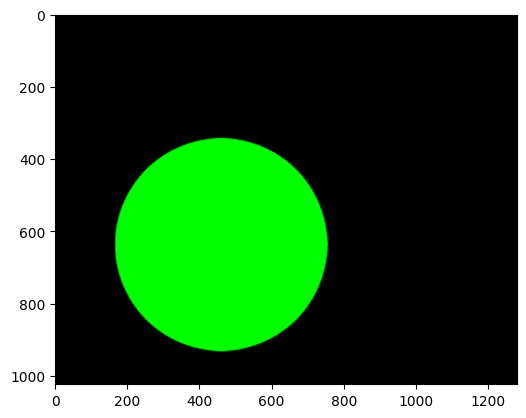

In [79]:
green_t = show_green_channel(img_t)

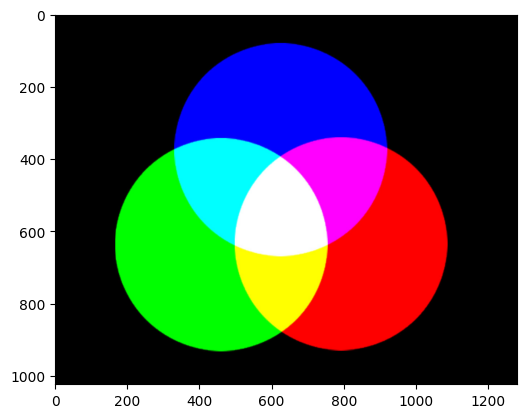

In [80]:
red_t = torch.squeeze(red_t)
blue_t = torch.squeeze(blue_t)
rgb_t = torch.stack([red_t, green_t, blue_t], dim=-1)
plt.imshow(rgb_t.numpy())

> <font color='orange'><b> TODO [ 탐구 ]</b></font>: 다른 이미지도 다뤄볼까요? url 을 바꿔서 다양한 이미지에 시도해 보세요! 🎁

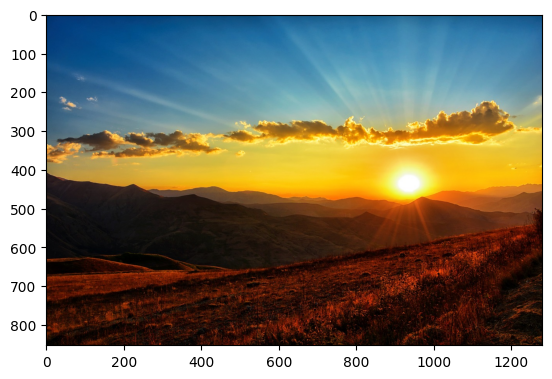

In [81]:
url = url = 'https://github.com/AI-rndt/BoostCamp_PyTorch/blob/main/images/sunset.jpg?raw=true'
image = bytearray(requests.get(url).content) # url로부터 content 가져오기
image = np.asarray(image, dtype=np.uint8) # numpy array로 변환하기
image = cv2.imdecode(image, cv2.IMREAD_COLOR) # opencv를 활용하여 image data decode하기
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # bgr to rgb, 채널 순서 변경
plt.imshow(image)
img_t = torch.from_numpy(image)

🎉🎉🎉 성공!!! 🎉🎉🎉


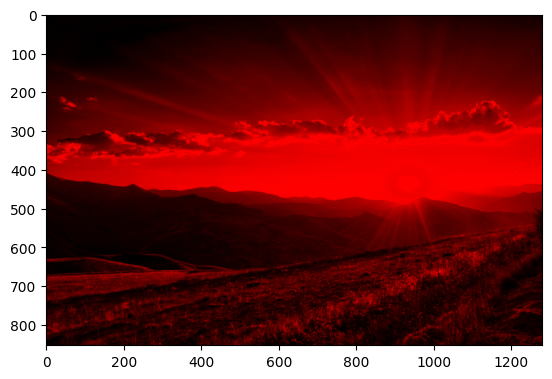

In [82]:
red_t = show_red_channel(img_t)

🎉🎉🎉 성공!!! 🎉🎉🎉


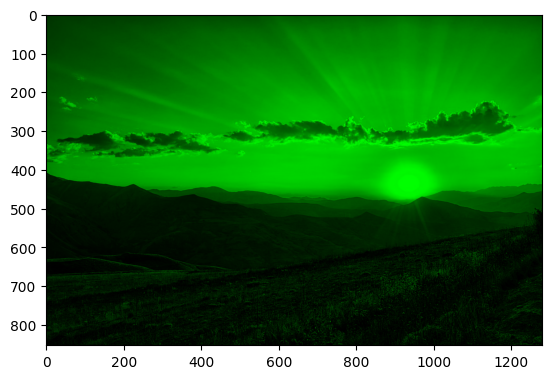

In [83]:
green_t = show_green_channel(img_t)

🎉🎉🎉 성공!!! 🎉🎉🎉


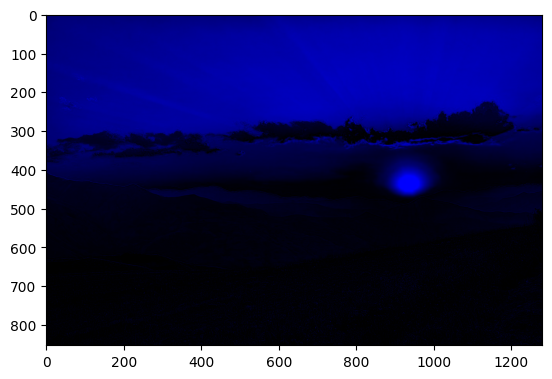

In [84]:
blue_t = show_blue_channel(img_t)

### **Task 7. Tensor를 조작하여 이미지 data augmentation 하기(응용)**

> 💡 <font color='red'><b> [ 학습 ]</b></font> 이미지 data augmentation 이란 원본 이미지에 변형을 가해 새로운 이미지 data를 만들어내는 방식을 말합니다. 변형을 가해 새로 추가된 이미지는 모델의 일반화 성능을 개선하고 과적합을 방지하는 역할을 합니다. 예를 들어, 이미지에 노이즈를 추가하거나, 이미지를 회전시키거나, 뒤집거나, 확대 및 축소하는 방식으로 변형을 가할 수 있습니다.

> <font color='green'><b>TODO [ 코드 작성 ]</b></font>: 이미지 Tensor에 random noise 추가하기

In [103]:
import torch

In [107]:
def add_random_noise(img_t, scale=30):
  # TODO 7-1) img_t와 모양(shape)이 같은 표준정규분포 난수 Tensor를 생성해 주세요. | 변수명 random_noise
  # TODO 7-1
  random_noise = torch.randn_like(img_t, dtype=torch.float32)
  print("random_noise.mean: {:.4f}".format(random_noise.mean()))
  print("random_noise.std: {:.4f}".format(random_noise.std()))
  print("random_noise.min: {:.4f}".format(random_noise.min()))
  print("random_noise.max: {:.4f}\n".format(random_noise.max()))

  random_noise *= scale

  # TODO 7-2) img_t의 자료형을 32-bit floating point로 변환한 후 random_noise를 더해 주세요. | 변수명: noise_added_img
  # TODO 7-2
  img_t = img_t.to(dtype=torch.float32)
  noise_added_img = img_t + random_noise

  # TODO 7-3) noise_added_img의 모든 값이 0과 255 사이의 값을 가지도록 제한해 주세요. hint: clip
  # TODO 7-3
  noise_added_img = torch.clamp(noise_added_img, 0, 255)

  # TODO 7-4) noise_added_img의 자료형을 torch.uint8로 변환해 주세요. hint: Tensor.type()
  # TODO 7-4
  noise_added_img = noise_added_img.to(dtype=torch.uint8)

  print("noise_added_img.min: {}".format(noise_added_img.min()))
  print("noise_added_img.max: {}\n".format(noise_added_img.max()))

  if noise_added_img.max() <= 255 and noise_added_img.min() >= 0:
    print("🎉🎉🎉 성공!!! 🎉🎉🎉")
  else:
    print("🙅 다시 도전해봐요!")
  return noise_added_img.numpy()

random_noise.mean: 0.0002
random_noise.std: 1.0001
random_noise.min: -5.0880
random_noise.max: 5.1953

noise_added_img.min: 0
noise_added_img.max: 255

🎉🎉🎉 성공!!! 🎉🎉🎉


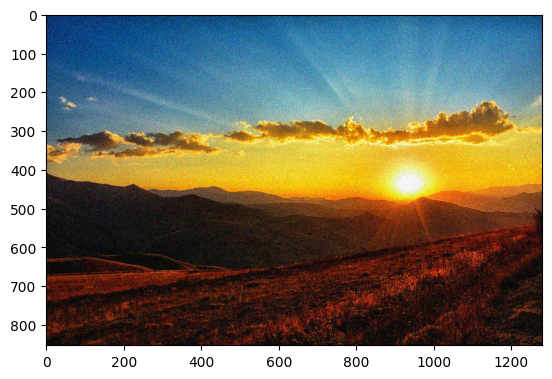

In [106]:
plt.imshow(add_random_noise(img_t, scale=25))

> <font color='orange'><b> TODO [ 탐구 ]</b></font>: noise의 scale을 0~70사이로 조정하면서 노이즈의 변화에 따른 이미지의 변화를 확인해 볼까요? 🎁 (이미지는 현재 uint8로 0-255 사이의 값을 가지며, noise의 값이 과하지 않도록 값을 제한하는 것이 좋습니다.)

random_noise.mean: 0.0006
random_noise.std: 1.0003
random_noise.min: -5.5210
random_noise.max: 5.3280

noise_added_img.min: 0
noise_added_img.max: 255

🎉🎉🎉 성공!!! 🎉🎉🎉


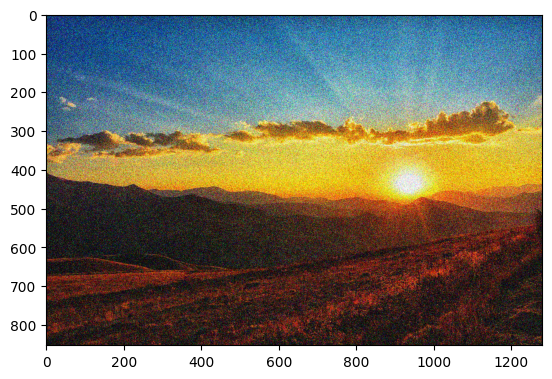

In [108]:
plt.imshow(add_random_noise(img_t, scale=55))

> <font color='green'><b>TODO [ 코드 작성 ]</b></font>: 이미지 Tensor의 모양 바꿔보기

🎉🎉🎉 성공!!! 🎉🎉🎉



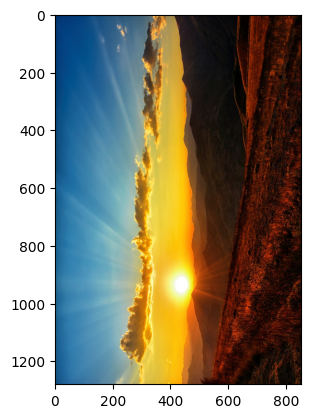

In [133]:
# TODO 7-5) img_t의 0번째 차원과 1번째 차원을 뒤바꿔 주세요. | 변수명: img_tp
# TODO 7-5
img_tp = img_t.transpose(1, 0)

if img_tp.shape[1] == img_t.shape[0]:
  print("🎉🎉🎉 성공!!! 🎉🎉🎉\n")
  plt.imshow(img_tp.numpy())
else:
  print("🙅 다시 도전해봐요!")

In [ ]:
# TODO 4-15) 0부터 12까지 1씩 증가하는 1-D Tensor를 생성해 주세요. | 변수명: t
# TODO 4-15
t = torch.arange(0, 12, 1)
print("t: {}".format(t))

# TODO 4-16) t Tensor의 shape을 [2, 2, 3]으로 변경해 주세요.
# 단 .reshape 메서드를 활용해 주세요.
# TODO 4-16
t = t.reshape(2, 2, 3)
print("t: {}\n".format(t))

# TODO 4-17) t Tensor의 2번째 차원과 1번째 차원을 바꾸어 주세요. | 변수명: transposed_t
# TODO 4-17
transposed_t = t.transpose(1, 2)
print("transposed_t: \n{}".format(transposed_t))
print("transposed_t.shape: {}\n".format(transposed_t.shape))

# TODO 4-18) 차원의 축을 변경하지 않고 t Tensor의 shape 을 [2, 3, 나머지]로 변경해 주세요. | 변수명: reshaped_t
# TODO 4-18
reshaped_t = t.reshape(2, 3, -1)

🎉🎉🎉 성공!!! 🎉🎉🎉



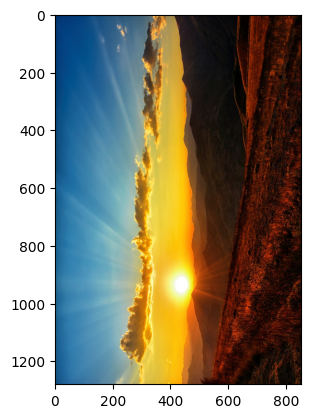

In [143]:
# TODO 7-6) img_t의 모양을 변경하여 img_reshaped에 대입할 때, 모양(shape)이 0번째 차원은 img_t의 1번째 차원의 크기가 되도록,
# 1번째 차원은 img_t의 0번째 차원의 크기가 되도록 변경해 주세요. | 변수명: img_reshaped
# TODO 7-6
img_reshaped = img_t.transpose(0, 1)

if img_reshaped.shape[1] == img_t.shape[0]:
  print("🎉🎉🎉 성공!!! 🎉🎉🎉\n")
  plt.imshow(img_reshaped.numpy())
else:
  print("🙅 다시 도전해봐요!")

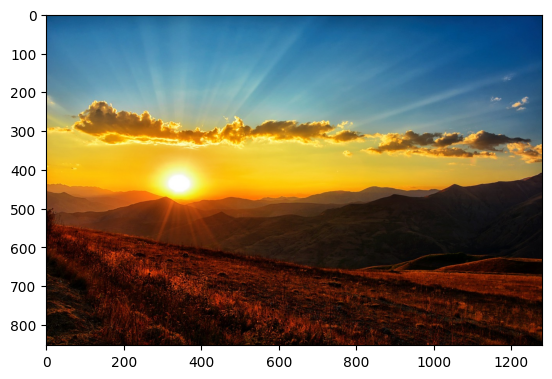

In [144]:
img_flipped = torch.fliplr(img_t)
plt.imshow(img_flipped.numpy())

> <font color='green'><b>TODO [ 코드 작성 ]</b></font>: 이미지 Tensor에서 원하는 부분만 선택하여 잘라내기 (crop)

🎉🎉🎉 성공!!! 🎉🎉🎉



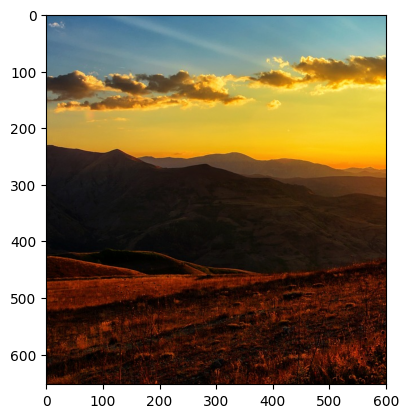

In [146]:
# TODO 7-7) img_t에서 0번째 차원은 200번째 요소부터, 1번째 차원은 100번째 요소부터 700번째까지(포함) 선택하여 잘라내 주세요. | 변수명: cropped
# TODO 7-7
cropped = img_t[200:, 100:701]
if cropped.shape[0] == (img_t.shape[0]-200) and cropped.shape[1] == 601:
  print("🎉🎉🎉 성공!!! 🎉🎉🎉\n")
  plt.imshow(cropped.numpy())
else:
  print("🙅 다시 도전해봐요!")

🎉🎉🎉 성공!!! 🎉🎉🎉



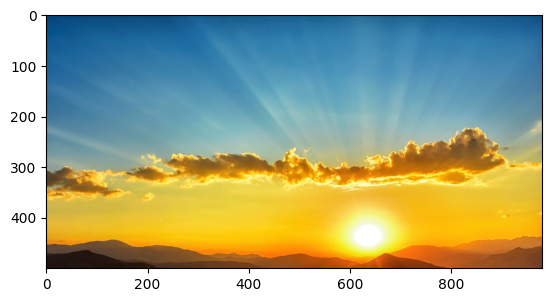

In [147]:
# TODO 7-8) img_t에서 0번째 차원은 처음부터 499번째 요소까지, 1번째 차원은 300번째 요소부터 끝까지 선택하여 잘라내 주세요. | 변수명: cropped
# TODO 7-8
cropped = img_t[:500, 300:]
if cropped.shape[0] == 500 and cropped.shape[1] == (img_t.shape[1]-300):
  print("🎉🎉🎉 성공!!! 🎉🎉🎉\n")
  plt.imshow(cropped.numpy())
else:
  print("🙅 다시 도전해봐요!")

### 🎉🎊🎉 축하드려요! 끝까지 해내셨군요!! 🎉🎊🎉
> 수고하셨습니다! 여기까지 오는 과정이 쉽지만은 않았을 수 있지만 PyTorch Tensor를 다루는 여러분의 이해와 실력은 비약적으로 성장했을겁니다! 다음 과제도 응원하겠습니다.

## 콘텐츠 라이선스

<hr style="height:5px;border:none;color:#5F71F7;background-color:#5F71F7">

<font color='red'><b>WARNING</font> : 본 교육 콘텐츠의 지식재산권은 재단법인 네이버커넥트에 귀속됩니다. 본 콘텐츠를 어떠한 경로로든 외부로 유출 및 수정하는 행위를 엄격히 금합니다. 다만, 비영리적 교육 및 연구활동에 한정되어 사용할 수 있으나 재단의 허락을 받아야 합니다. 이를 위반하는 경우, 관련 법률에 따라 책임을 질 수 있습니다. </b>